In [8]:
import ccxt.async_support
from IPython.display import clear_output
import time
import asyncio
from matplotlib import pyplot as plt
import numpy as np  
from sklearn import linear_model,metrics

In [16]:
async def price(exchange,symbol):
    pri=exchange.fetch_ohlcv(symbol,timeframe='1m',limit=1)
    return pri[0][4]


In [17]:
async def bid(exchange,symbol):
    bid_l=exchange.fetch_order_book(symbol)
    bid_v=0
    for p,v in bid_l['bids']:
        bid_v=(p*v)+bid_v
    return bid_v

In [18]:
async def ask(exchange,symbol):
    ask_l=exchange.fetch_order_book(symbol)
    ask_v=0
    for p,v in ask_l['asks']:
        ask_v=(p*v)+ask_v
    return ask_v

R Squarred Value: 0.0023598064284997555


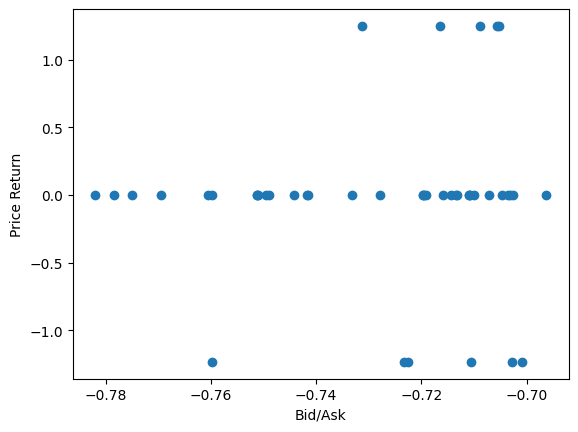

CancelledError: 

In [28]:
#Perform regression and plot of ratio of return and bid/ask ratio
async def main():
    symbol=str(input("Enter the Symbol:"))
    bid_ask=[]
    price_ret=[]
    price_l=[]
    print("Regression for:",symbol)
    while True:
        exchange=ccxt.binance()
        bid_ask_p=await asyncio.gather(ask(exchange,symbol),bid(exchange,symbol),price(exchange,symbol))
        if len(price_l)<1:
            price_l.append(bid_ask_p[2])
        else:
            price_ret.append(((bid_ask_p[2]-price_l[-1])/price_l[-1])*100)
            price_l.append(bid_ask_p[2])
            bid_ask.append(np.log(bid_ask_p[1]/bid_ask_p[0]))
            model=linear_model.LinearRegression()
            model.fit(np.array(bid_ask).reshape(-1,1),np.array(price_ret))
            clear_output(wait=True)
            print("R Squarred Value:",metrics.r2_score(np.array(price_ret),model.predict(np.array(bid_ask).reshape(-1,1))))
            plt.scatter(bid_ask,price_ret)
            plt.xlabel("Bid/Ask")
            plt.ylabel("Price Return")
            plt.show()

await main()
    
